# Test Acoustic Classifier Model

This notebook tests the trained acoustic anomaly detection model on sample audio files:
- 2 normal audio samples
- 1 abnormal audio sample

The model uses a **fully-connected autoencoder** (FC layers: Input→64→64→8→64→64→Output) trained on normal sounds to detect anomalies through reconstruction error.

**Architecture:**
- Encoder: FC(4096, 64) → FC(64, 64) → FC(64, 8) [All ReLU]
- Decoder: FC(8, 64) → FC(64, 64) → FC(64, 4096) [ReLU, ReLU, Linear]
- Bottleneck: 8 dimensions (tight compression for selective reconstruction)

## Setup: Install Dependencies

In [2]:
# Install required packages if not already installed
import subprocess
import sys

required_packages = [
    'numpy>=1.26',
    'pandas>=2.2',
    'torch>=2.2',
    'torchaudio>=2.2',
    'soundfile',
    'matplotlib>=3.8',
    'PyYAML>=6.0'
]

print("Installing required packages...")
for package in required_packages:
    try:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', package])
    except Exception as e:
        print(f"Note: {package} - {e}")

print("✓ All dependencies ready")

Installing required packages...
✓ All dependencies ready


## 1. Import Required Libraries

In [3]:
import sys
import os
from pathlib import Path

# Add project src to path
sys.path.insert(0, str(Path('project/src').resolve()))

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

# Import project modules (except model - we'll reload that in next cell)
from features import LogMelExtractor, load_norm_stats, normalize_patches
from utils import load_config, get_device

print("✓ Basic libraries imported successfully")

✓ Basic libraries imported successfully


## 1.5 Load Model Architecture (with forced reload)

**If you see an error about architecture mismatch:**
The Python kernel cached the old model definition. Running this cell will force reload the new architecture from disk.

In [4]:
# Force reload of the model module to get the latest architecture changes
import importlib
if 'model' in sys.modules:
    importlib.reload(sys.modules['model'])
    print("✓ Reloaded model module from disk")

# Now import the model class
from model import ConvAutoencoder

# Verify the architecture by checking the first layer type
test_model = ConvAutoencoder()
first_encoder_layer = list(test_model.encoder.children())[0]

if hasattr(first_encoder_layer, 'in_features'):
    print("✓ Model architecture: FULLY-CONNECTED (correct!)")
    print(f"  Encoder: {first_encoder_layer.in_features} → 64 → 64 → 8")
    print(f"  Decoder: 8 → 64 → 64 → {first_encoder_layer.in_features}")
    print("  Ready to load trained checkpoint!")
elif hasattr(first_encoder_layer, 'in_channels'):
    print("✗ Model architecture: CONVOLUTIONAL (cached old version)")
    print("\n⚠️ SOLUTION: Restart the notebook kernel!")
    print("  1. Click 'Restart' button in the toolbar above")
    print("  2. Or: Kernel → Restart Kernel")
    print("  3. Then run all cells from the beginning")
    raise RuntimeError("Please restart kernel to reload the updated model architecture")

✓ Model architecture: FULLY-CONNECTED (correct!)
  Encoder: 4096 → 64 → 64 → 8
  Decoder: 8 → 64 → 64 → 4096
  Ready to load trained checkpoint!


In [5]:
# Force reload of the model module to get the latest architecture
import importlib
if 'model' in sys.modules:
    importlib.reload(sys.modules['model'])

# Now import
from model import ConvAutoencoder

# Verify the architecture
test_model = ConvAutoencoder()
print("Current model architecture:")
print(test_model)
print("\n" + "="*60)

# Check if it's fully-connected or convolutional
first_layer = list(test_model.encoder.children())[0]
if hasattr(first_layer, 'in_features'):
    print("✓ Model has FULLY-CONNECTED layers (correct!)")
    print(f"  Encoder input: {first_layer.in_features} → {first_layer.out_features}")
elif hasattr(first_layer, 'in_channels'):
    print("✗ Model has CONVOLUTIONAL layers (outdated!)")
    print(f"  You need to RESTART THE KERNEL to reload the new architecture")
print("="*60)

Current model architecture:
ConvAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=4096, out_features=64, bias=True)
    (1): ReLU(inplace=True)
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU(inplace=True)
    (4): Linear(in_features=64, out_features=8, bias=True)
    (5): ReLU(inplace=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=8, out_features=64, bias=True)
    (1): ReLU(inplace=True)
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU(inplace=True)
    (4): Linear(in_features=64, out_features=4096, bias=True)
  )
)

✓ Model has FULLY-CONNECTED layers (correct!)
  Encoder input: 4096 → 64


## 2. Load Trained Model and Configuration

**⚠️ Important:** The model architecture has been updated to fully-connected layers. If you get a `RuntimeError` about size mismatch when loading the checkpoint, you need to retrain the model first:

```bash
cd models\04_acoustic_classifier\project\src
python train.py --config ..\configs\default.yaml
```

In [6]:
# Load configuration
config_path = "project/configs/default.yaml"
config = load_config(config_path)

# Load model
device = get_device(config["training"]["device"])
model = ConvAutoencoder().to(device)

checkpoint_path = Path("project/outputs/checkpoints/best.pt")
if not checkpoint_path.exists():
    raise FileNotFoundError(
        f"Model checkpoint not found at: {checkpoint_path}\n\n"
        "Please train the model first:\n"
        "  cd models\\04_acoustic_classifier\\project\\src\n"
        "  python train.py --config ..\\configs\\default.yaml"
    )

# Try to load checkpoint with error handling
try:
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()
except RuntimeError as e:
    if "size mismatch" in str(e):
        raise RuntimeError(
            "❌ Model architecture mismatch!\n\n"
            "The checkpoint was trained with the OLD convolutional architecture,\n"
            "but the code now uses the NEW fully-connected architecture.\n\n"
            "You need to RETRAIN the model with the new architecture:\n\n"
            "  cd models\\04_acoustic_classifier\\project\\src\n"
            "  python train.py --config ..\\configs\\default.yaml\n\n"
            "The new model uses a fully-connected autoencoder (Input→64→64→8→64→64→Output)\n"
            "which should provide better anomaly detection."
        ) from e
    else:
        raise

# Load normalization statistics
norm_stats_path = Path("project/outputs/norm_stats.json")
norm_stats = load_norm_stats(norm_stats_path)

# Load threshold
threshold_path = Path("project/outputs/eval/threshold.json")
if threshold_path.exists():
    import json
    with open(threshold_path) as f:
        threshold_info = json.load(f)
    threshold = threshold_info["threshold"]
else:
    threshold = 0.05  # Default fallback

# Initialize feature extractor
extractor = LogMelExtractor(config)

print(f"✓ Model loaded from epoch {checkpoint['epoch']}")
print(f"✓ Normalization stats: mean={norm_stats['mean']:.4f}, std={norm_stats['std']:.4f}")
print(f"✓ Anomaly threshold: {threshold:.6f}")
print(f"✓ Device: {device}")

✓ Model loaded from epoch 50
✓ Normalization stats: mean=-5.6995, std=2.2760
✓ Anomaly threshold: 0.255148
✓ Device: cpu


## 3. Load Test Samples

In [9]:
# Load test manifests
test_normal_df = pd.read_csv("project/outputs/manifests/test_normal.csv")
test_abnormal_df = pd.read_csv("project/outputs/manifests/test_abnormal.csv")

# Select 2 normal samples and 1 abnormal sample
normal_samples = test_normal_df.sample(n=2, random_state=42)
abnormal_samples = test_abnormal_df.sample(n=1, random_state=42)

# Combine them
test_samples = pd.concat([normal_samples, abnormal_samples], ignore_index=True)

print("Selected test samples:")
for idx, row in test_samples.iterrows():
    filename = Path(row['filepath']).name
    print(f"  {idx+1}. {filename} - {row['true_label']}")

Selected test samples:
  1. 00000056.wav - normal
  2. 00000292.wav - normal
  3. 00000044.wav - abnormal


## 4. Compute Anomaly Scores

In [10]:
def score_file(filepath, model, extractor, norm_stats, device):
    """Compute anomaly score for a single audio file."""
    # Extract features
    patches = extractor.file_to_patches(filepath)
    patches = normalize_patches(patches, norm_stats["mean"], norm_stats["std"]).to(device)
    
    # Compute reconstruction error
    with torch.no_grad():
        recon = model(patches)
        err = (recon - patches) ** 2
        patch_scores = err.mean(dim=(1, 2, 3)).cpu().numpy()
    
    # Aggregate score (mean)
    anomaly_score = float(np.mean(patch_scores))
    return anomaly_score, patches.cpu()

# Score each sample
results = []
spectrograms = []

for idx, row in test_samples.iterrows():
    filepath = row['filepath']
    true_label = row['true_label']
    
    # Compute score
    score, patches = score_file(filepath, model, extractor, norm_stats, device)
    
    # Predict label
    predicted_label = "abnormal" if score >= threshold else "normal"
    is_correct = predicted_label == true_label
    
    results.append({
        'filename': Path(filepath).name,
        'true_label': true_label,
        'anomaly_score': score,
        'predicted_label': predicted_label,
        'correct': '✓' if is_correct else '✗'
    })
    
    spectrograms.append(patches[0, 0].numpy())

# Display results
results_df = pd.DataFrame(results)
print("\n=== Prediction Results ===")
print(f"Threshold: {threshold:.6f}\n")
print(results_df.to_string(index=False))
print(f"\nAccuracy: {results_df['correct'].str.contains('✓').sum()}/{len(results_df)}")


=== Prediction Results ===
Threshold: 0.255148

    filename true_label  anomaly_score predicted_label correct
00000056.wav     normal       0.215815          normal       ✓
00000292.wav     normal       0.186018          normal       ✓
00000044.wav   abnormal       0.264679        abnormal       ✓

Accuracy: 3/3


## 5. Visualize Log-Mel Spectrograms

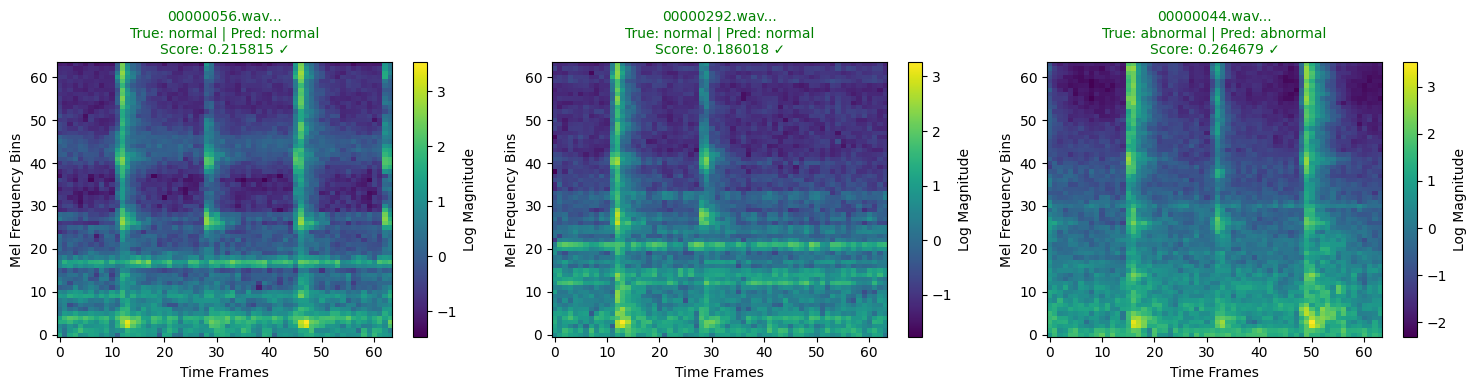


Normal samples should have LOW scores (< 0.255148)
Abnormal samples should have HIGH scores (>= 0.255148)


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, (result, spectrogram) in enumerate(zip(results, spectrograms)):
    ax = axes[idx]
    
    # Plot spectrogram
    im = ax.imshow(spectrogram, aspect='auto', origin='lower', cmap='viridis')
    
    # Title with results
    color = 'green' if result['correct'] == '✓' else 'red'
    title = f"{result['filename'][:20]}...\n"
    title += f"True: {result['true_label']} | Pred: {result['predicted_label']}\n"
    title += f"Score: {result['anomaly_score']:.6f} {result['correct']}"
    ax.set_title(title, fontsize=10, color=color)
    
    ax.set_xlabel('Time Frames')
    ax.set_ylabel('Mel Frequency Bins')
    plt.colorbar(im, ax=ax, label='Log Magnitude')

plt.tight_layout()
plt.show()

print(f"\n{'='*60}")
print(f"Normal samples should have LOW scores (< {threshold:.6f})")
print(f"Abnormal samples should have HIGH scores (>= {threshold:.6f})")
print(f"{'='*60}")

## 6. Compare Results

Visualize the anomaly scores compared to the threshold.

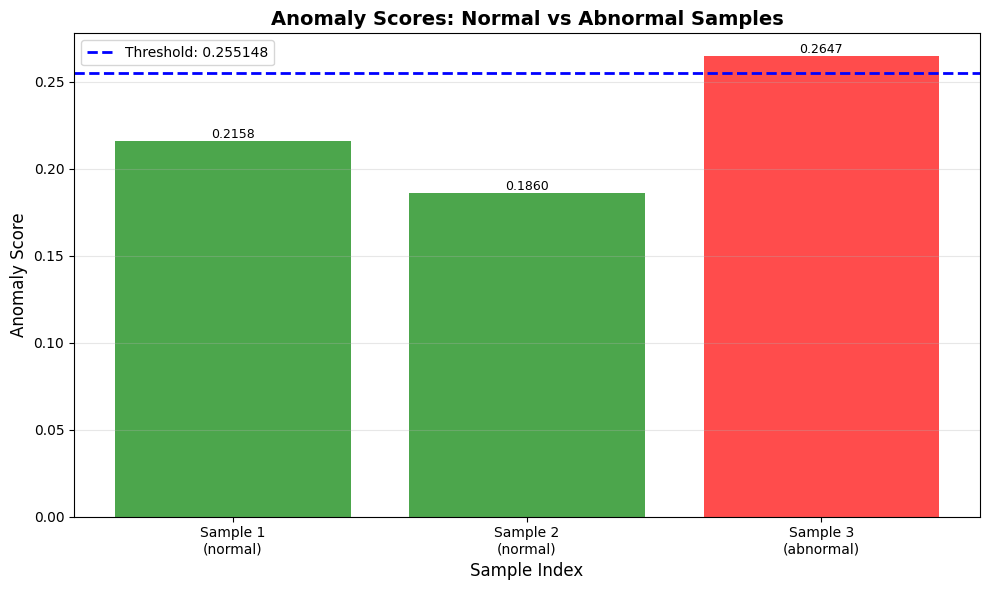


✓ Testing complete!


In [12]:
fig, ax = plt.subplots(figsize=(10, 6))

# Plot anomaly scores
colors = ['green' if label == 'normal' else 'red' for label in results_df['true_label']]
bars = ax.bar(range(len(results_df)), results_df['anomaly_score'], color=colors, alpha=0.7)

# Add threshold line
ax.axhline(y=threshold, color='blue', linestyle='--', linewidth=2, label=f'Threshold: {threshold:.6f}')

# Labels and formatting
ax.set_xlabel('Sample Index', fontsize=12)
ax.set_ylabel('Anomaly Score', fontsize=12)
ax.set_title('Anomaly Scores: Normal vs Abnormal Samples', fontsize=14, fontweight='bold')
ax.set_xticks(range(len(results_df)))
ax.set_xticklabels([f"Sample {i+1}\n({label})" for i, label in enumerate(results_df['true_label'])], fontsize=10)
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Add score values on bars
for i, (bar, score) in enumerate(zip(bars, results_df['anomaly_score'])):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{score:.4f}',
            ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print("\n✓ Testing complete!")

## 7. Diagnostic Analysis

Let's analyze why the abnormal sample has low anomaly score and test more samples.

In [13]:
# Test 10 random abnormal samples to see the distribution of scores
print("Testing 10 random abnormal samples...\n")

abnormal_test = test_abnormal_df.sample(n=10, random_state=123)
abnormal_scores = []

for idx, row in abnormal_test.iterrows():
    filepath = row['filepath']
    score, _ = score_file(filepath, model, extractor, norm_stats, device)
    abnormal_scores.append(score)
    status = "✓ DETECTED" if score >= threshold else "✗ MISSED"
    print(f"{Path(filepath).name}: {score:.6f} {status}")

print(f"\nAbnormal Detection Rate: {sum(s >= threshold for s in abnormal_scores)}/{len(abnormal_scores)}")
print(f"Min score: {min(abnormal_scores):.6f}")
print(f"Max score: {max(abnormal_scores):.6f}")
print(f"Mean score: {np.mean(abnormal_scores):.6f}")
print(f"Threshold: {threshold:.6f}")

# Compare with normal samples
print("\n" + "="*60)
print("Testing 10 random normal samples...\n")

normal_test = test_normal_df.sample(n=10, random_state=123)
normal_scores = []

for idx, row in normal_test.iterrows():
    filepath = row['filepath']
    score, _ = score_file(filepath, model, extractor, norm_stats, device)
    normal_scores.append(score)
    status = "✓ CORRECT" if score < threshold else "✗ FALSE ALARM"
    print(f"{Path(filepath).name}: {score:.6f} {status}")

print(f"\nNormal Specificity: {sum(s < threshold for s in normal_scores)}/{len(normal_scores)}")
print(f"Min score: {min(normal_scores):.6f}")
print(f"Max score: {max(normal_scores):.6f}")
print(f"Mean score: {np.mean(normal_scores):.6f}")

Testing 10 random abnormal samples...

00000004.wav: 0.192274 ✗ MISSED
00000117.wav: 0.144809 ✗ MISSED
00000112.wav: 0.186269 ✗ MISSED
00000104.wav: 0.247606 ✗ MISSED
00000031.wav: 0.209645 ✗ MISSED
00000024.wav: 0.194006 ✗ MISSED
00000110.wav: 0.102170 ✗ MISSED
00000062.wav: 0.214725 ✗ MISSED
00000016.wav: 0.141853 ✗ MISSED
00000035.wav: 0.149718 ✗ MISSED

Abnormal Detection Rate: 0/10
Min score: 0.102170
Max score: 0.247606
Mean score: 0.178308
Threshold: 0.255148

Testing 10 random normal samples...

00000668.wav: 0.123001 ✓ CORRECT
00000232.wav: 0.127461 ✓ CORRECT
00000403.wav: 0.119604 ✓ CORRECT
00000974.wav: 0.113362 ✓ CORRECT
00000530.wav: 0.185329 ✓ CORRECT
00000562.wav: 0.123358 ✓ CORRECT
00000663.wav: 0.136949 ✓ CORRECT
00000345.wav: 0.197348 ✓ CORRECT
00000422.wav: 0.124629 ✓ CORRECT
00000463.wav: 0.119508 ✓ CORRECT

Normal Specificity: 10/10
Min score: 0.113362
Max score: 0.197348
Mean score: 0.137055


C:\Users\rayen\AppData\Local\Temp\ipykernel_23172\25801138.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(data_to_plot, positions=positions, widths=0.6, patch_artist=True,


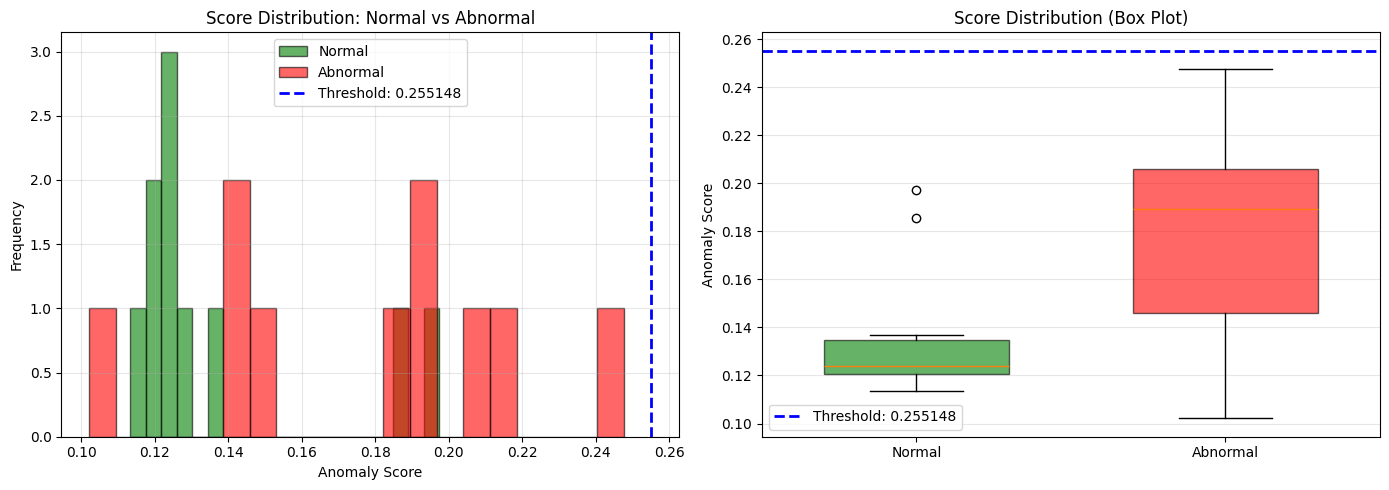


Separation metric: 0.6003
(Higher is better - indicates how well separated the distributions are)


In [14]:
# Visualize the score distributions
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Histogram comparison
ax1.hist(normal_scores, bins=20, alpha=0.6, label='Normal', color='green', edgecolor='black')
ax1.hist(abnormal_scores, bins=20, alpha=0.6, label='Abnormal', color='red', edgecolor='black')
ax1.axvline(threshold, color='blue', linestyle='--', linewidth=2, label=f'Threshold: {threshold:.6f}')
ax1.set_xlabel('Anomaly Score')
ax1.set_ylabel('Frequency')
ax1.set_title('Score Distribution: Normal vs Abnormal')
ax1.legend()
ax1.grid(alpha=0.3)

# Box plot comparison
data_to_plot = [normal_scores, abnormal_scores]
positions = [1, 2]
bp = ax2.boxplot(data_to_plot, positions=positions, widths=0.6, patch_artist=True,
                 labels=['Normal', 'Abnormal'])
bp['boxes'][0].set_facecolor('green')
bp['boxes'][0].set_alpha(0.6)
bp['boxes'][1].set_facecolor('red')
bp['boxes'][1].set_alpha(0.6)
ax2.axhline(threshold, color='blue', linestyle='--', linewidth=2, label=f'Threshold: {threshold:.6f}')
ax2.set_ylabel('Anomaly Score')
ax2.set_title('Score Distribution (Box Plot)')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Calculate separation metric
separation = abs(np.mean(abnormal_scores) - np.mean(normal_scores)) / (np.std(normal_scores) + np.std(abnormal_scores) + 1e-8)
print(f"\n{'='*60}")
print(f"Separation metric: {separation:.4f}")
print(f"(Higher is better - indicates how well separated the distributions are)")
print(f"{'='*60}")

## 8. Recommendations for Improvement

Based on the analysis above, here are potential solutions to improve abnormal detection:

### Model Architecture (Already Optimized)

✓ **Fully-Connected Autoencoder with 8-dimensional bottleneck**  
This tight compression forces the model to learn only the most essential features, making it more selective about what it can reconstruct well.

### Possible Issues & Solutions:

**1. Poor Score Separation**
   - If normal and abnormal scores overlap significantly, the model struggles to distinguish them
   - **Solution**: Enable supervised threshold tuning (set `enable_supervised_threshold_tuning: true` in config)

**2. Model Too Generalized**
   - Training on all 4 machine IDs (3,691 samples) creates a very diverse "normal" distribution
   - **Solution**: Train separate models per machine ID for more specialized detection
   - **Alternative**: Use `machine_id: "id_00"` in config to train on single ID

**3. Aggregation Method**
   - Mean averaging might smooth out anomalous peaks
   - **Solution**: Try `aggregation: "p95"` to focus on worst-case patches

**4. Threshold Selection**
   - 99th percentile might be too conservative (only top 1% flagged)
   - **Solution**: Lower to 95th or 90th percentile for more sensitivity

### Quick Config Changes to Try:

```yaml
# In default.yaml
inference:
  aggregation: "p95"  # Use 95th percentile instead of mean
  threshold_percentile: 95.0  # More sensitive (was 99.0)

evaluation:
  enable_supervised_threshold_tuning: true  # Find optimal threshold using F1 score
```

### Training Per Machine ID (More Specialized):

```yaml
# In default.yaml
paths:
  machine_id: "id_00"  # Train on single ID instead of "all"
```